# Exam Model Training

In [60]:
import pandas as pd

df = pd.read_csv("data/students_depression_prepared.csv")
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1.0,33.0,3.2,5.0,8.97,2.0,5.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0
1,0.0,24.0,3.8,2.0,5.90,5.0,5.0,1.0,1.0,0.0,3.0,1.0,1.0,0.0
2,1.0,31.0,2.1,3.0,7.03,5.0,1.0,0.0,1.0,0.0,9.0,0.0,1.0,0.0
3,0.0,28.0,1.0,3.0,5.59,2.0,8.0,1.0,1.0,1.0,4.0,4.0,1.0,1.0
4,0.0,25.0,1.0,4.0,8.13,3.0,5.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0


As the task asks, I should train a model that can determine whether a student is experiencing a depressive phase therefor along the training I should focuse on having the highest recall score.

In [61]:
abs(df.corr()["Depression"]).sort_values()[::-1]

Depression                               1.000000
Have you ever had suicidal thoughts ?    0.546387
Academic Pressure                        0.474810
Financial Stress                         0.364303
Age                                      0.227023
Work/Study Hours                         0.208141
Dietary Habits                           0.207346
Study Satisfaction                       0.168748
Degree                                   0.113825
Sleep Duration                           0.084907
Family History of Mental Illness         0.053331
City                                     0.038570
CGPA                                     0.020739
Gender                                   0.001446
Name: Depression, dtype: float64

Now my plan is to select some features to train on them several models select the best model and working with to explain the influence of features on it.

In [62]:
correlation_columns = ['pearson', 'kendall', 'spearman']
correlation_dataframe = pd.DataFrame({}, columns=correlation_columns)

for corr_method in correlation_columns:
    correlation_dataframe[corr_method] = abs(df.corr(method=corr_method)["Depression"]).sort_values()[::-1]

correlation_dataframe

,pearson,kendall,spearman
Depression,1.000000,1.000000,1.000000
Have you ever had suicidal thoughts ?,0.546387,0.546387,0.546387
Academic Pressure,0.474810,0.423560,0.472311
Financial Stress,0.364303,0.325410,0.363550
Age,0.227023,0.190020,0.225916
Work/Study Hours,0.208141,0.170509,0.200261
Dietary Habits,0.207346,0.196324,0.208006
Study Satisfaction,0.168748,0.151206,0.168915
Degree,0.113825,0.107184,0.113748
Sleep Duration,0.084907,0.079256,0.086721


In [63]:
from kydavra import PearsonCorrelationSelector

pearson = PearsonCorrelationSelector(min_corr=0.2)
selected_columns = pearson.select(df, 'Depression')

In [64]:
selected_columns.append("Depression")
selected_columns

['Age',
 'Academic Pressure',
 'Dietary Habits',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Depression']

In [65]:
df_training = df[selected_columns]

Now let's check if the dataset need class balancing.

16300/11515


<BarContainer object of 2 artists>

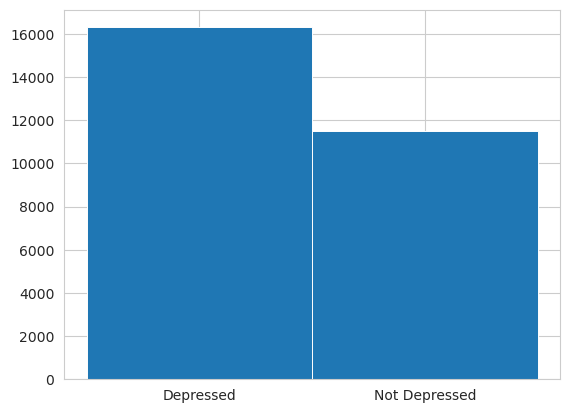

In [66]:
from matplotlib import pyplot as plt

print(f"{len(df_training[df_training["Depression"]==1])}/{len(df_training[df_training["Depression"]==0])}")
fig, ax = plt.subplots()

y = [len(df_training[df_training["Depression"]==1]), len(df_training[df_training["Depression"]==0])]
ax.bar(["Depressed","Not Depressed"], y, width=1,  linewidth=0.7)

As we could see, there is a significant difference in the class numbers, therefore we need to apply the class balancing methods.

Before proceeding to Class Balancing we need to split data into training and testing.

In [67]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_training, test_size=0.3, random_state=40)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

In [68]:
train.shape

(19470, 7)

In [ ]:
from crucio import SMOTEENN

smoteenn = SMOTEENN()
balanced_df = smoteenn.balance(train, "Depression")
balanced_df.shape

Now that we have everything ready for training let's train it.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

models = [
    LogisticRegression(),
    RandomForestClassifier(),
    SVC(),
    GaussianNB(),
    DecisionTreeClassifier(),
]

X = balanced_df.drop("Depression", axis=1)
y = balanced_df["Depression"]

x_test = test.drop("Depression", axis=1)
y_test = test["Depression"]

results = pd.DataFrame({})
for model in models:
    model.fit(X, y)

    y_pred = model.predict(x_test)
    score = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results = pd.concat([
        results,
        pd.DataFrame({
            "Accuracy": score,
            "Recall": recall,
        },
            index=[model.__class__.__name__]
        )
    ],)

In [34]:
results

,Accuracy,Recall
LogisticRegression,0.836549,0.834057
RandomForestClassifier,0.823247,0.852449
SVC,0.837507,0.839430
GaussianNB,0.828400,0.818144
DecisionTreeClassifier,0.798203,0.817318


As we could see, the biggest recall score is for RandomForestClassifie. Now I would like to improve these performances.

In [46]:
from sklearn.model_selection import GridSearchCV

tuned_parameters = {
    'n_estimators': range(50, 200, 50),
    'max_depth': range(1, 20, 1),
    'max_features': ["auto", "sqrt", "log2"],
    'criterion': ['gini', "entropy", "log_loss"]
}

clf = GridSearchCV(RandomForestClassifier(), tuned_parameters, scoring='recall', n_jobs=12)
clf.fit(X, y)

print(clf.best_params_)
print(clf.best_score_)


{'criterion': 'log_loss', 'max_depth': 13, 'max_features': 'log2', 'n_estimators': 50}
0.9207456014330125


0.8322348711803476
0.8605083694978302


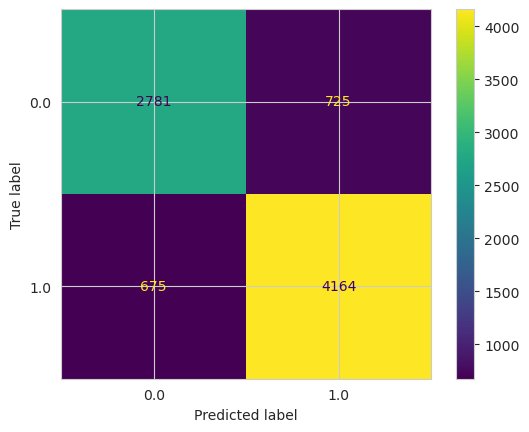

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

best_params = {'criterion': 'log_loss', 'max_depth': 13, 'max_features': 'log2', 'n_estimators': 50}
clf = RandomForestClassifier(**best_params)

model = Pipeline([("scaler", StandardScaler()),('clf', clf)])

model.fit(X, y)
y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Here, the FN corner makes me a bit worried, but for now I don't know what caused this. Btw because the classifier is RandomForest we don't need to apply any scaling for data.

In [56]:
import shap
shap.initjs()

ExactExplainer explainer: 8346it [03:23, 38.90it/s]                          


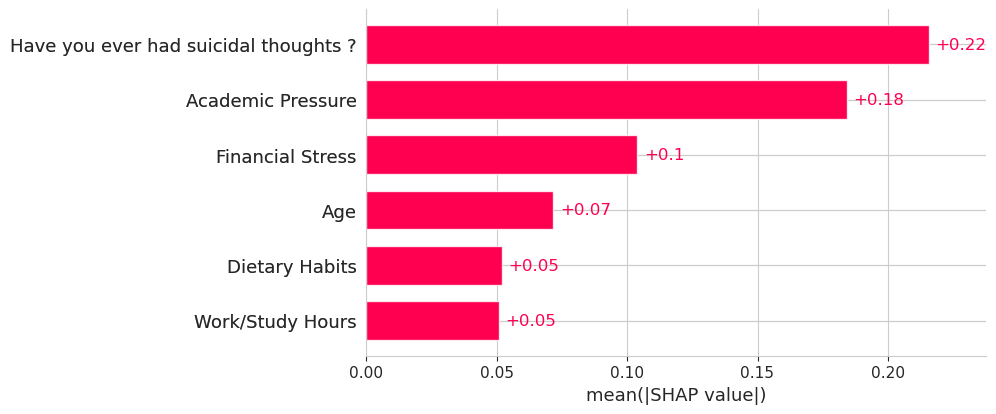

In [58]:

explainer = shap.Explainer(model.predict, X, feature_names = list(train.columns)[:-1])

shap_values = explainer(x_test)
shap.plots.bar(shap_values, max_display=14)

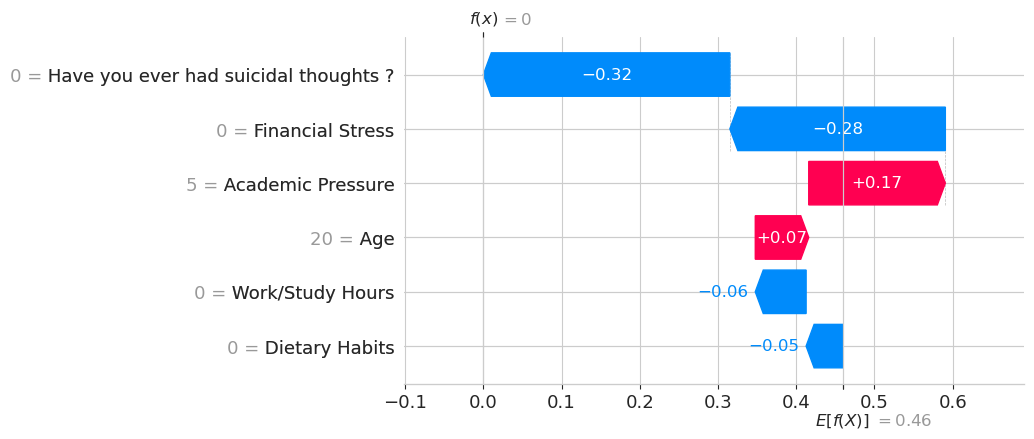

In [59]:
shap.plots.waterfall(shap_values[0], max_display=14)